# TP 1 — Modèles paramétriques sur SAheart
*Séance 2 · 18 septembre 2026 — corrigé*

Objectif : programmer le classifieur de Bayes naïf à la main, puis le comparer à scikit-learn, LDA et QDA.

In [1]:
import sys; sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import utils
utils.style()

GRAINE = 42

## Exercice 1 — Prise en main et découpage
### 1.1 Charger et décrire

In [2]:
df = utils.load_saheart()
df.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
row.names,,,,,,,,,,
1,160,12.00,5.73,23.11,1,49,25.30,97.20,52,1
2,144,0.01,4.41,28.61,0,55,28.87,2.06,63,1
3,118,0.08,3.48,32.28,1,52,29.14,3.81,46,0
4,170,7.50,6.41,38.03,1,51,31.99,24.26,58,1
5,134,13.60,3.50,27.78,1,60,25.99,57.34,49,1


In [3]:
n, p = df.shape
print(f"{n} observations, {p} colonnes : {p - 1} variables explicatives + la cible chd")

effectifs = df["chd"].value_counts().sort_index()
proportions = df["chd"].value_counts(normalize=True).sort_index()
print(pd.DataFrame({"effectif": effectifs, "proportion": proportions.round(3)})
        .rename(index={0: "sain (0)", 1: "malade (1)"}))

# Le classifieur constant « toujours sain » se trompe sur tous les malades.
erreur_constante = (df["chd"] == 1).mean()
print(f"\nErreur du classifieur constant « sain » : {erreur_constante:.1%}")

462 observations, 10 colonnes : 9 variables explicatives + la cible chd
            effectif  proportion
chd                             
sain (0)         302       0.654
malade (1)       160       0.346

Erreur du classifieur constant « sain » : 34.6%


**Réponses.**
- 462 observations, 9 variables explicatives (+ la cible `chd`).
- 302 sains (65,4 %) et 160 malades (34,6 %) : les classes sont déséquilibrées.
- Un classifieur qui répond toujours « sain » se trompe exactement sur les malades : **34,6 % d'erreur**. Tout modèle doit faire mieux que ça pour être utile.

### 1.2 Regarder les données

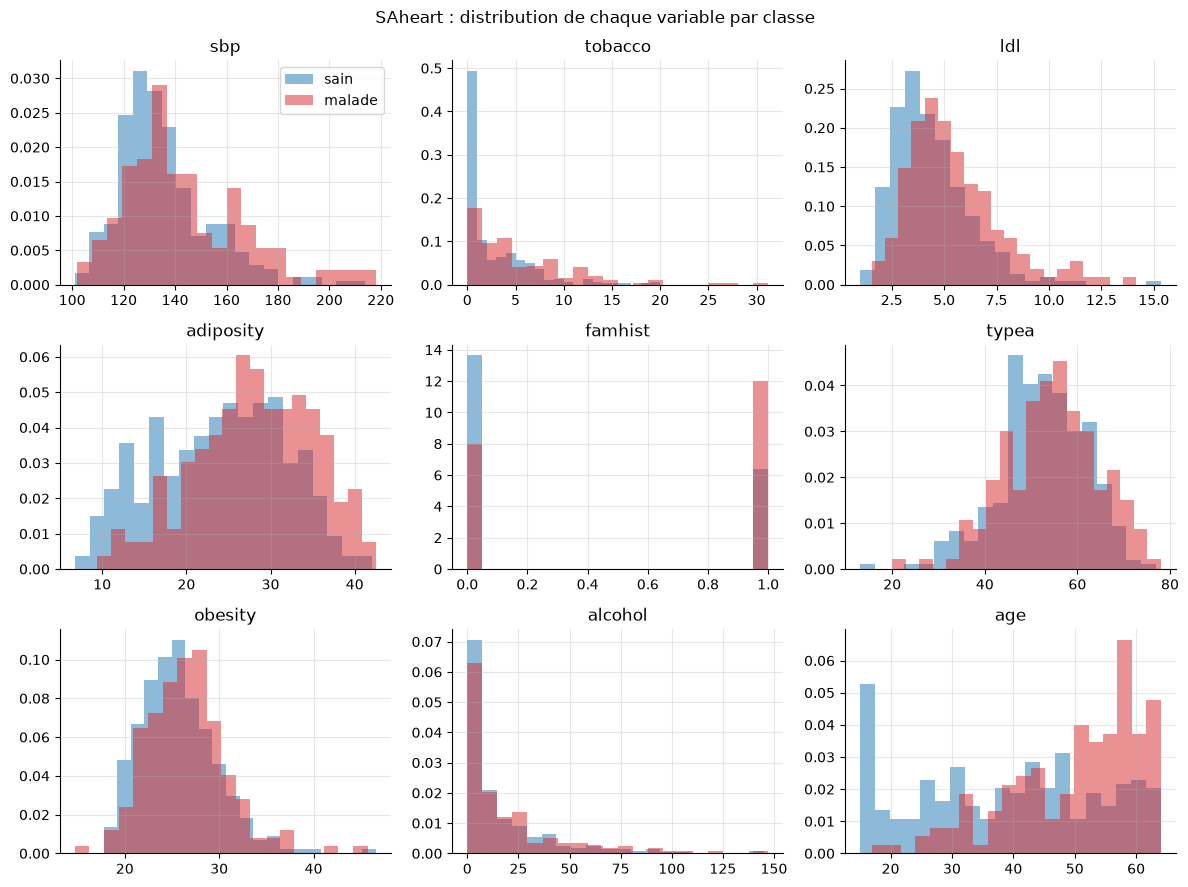

In [4]:
fig = utils.plot_saheart_apercu(df)

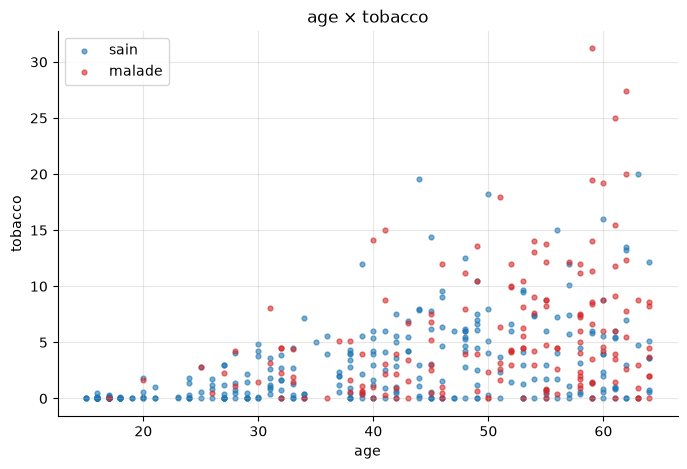

In [5]:
fig, ax = plt.subplots()
for k, c, nom in [(0, "tab:blue", "sain"), (1, "tab:red", "malade")]:
    d = df[df.chd == k]
    ax.scatter(d["age"], d["tobacco"], s=12, c=c, alpha=0.6, label=nom)
ax.set_xlabel("age"); ax.set_ylabel("tobacco"); ax.legend()
ax.set_title("age × tobacco");

**Commentaire.** Les histogrammes par classe se recouvrent fortement : aucune variable ne sépare seule les deux classes. Les plus discriminantes sont `age`, `tobacco`, `ldl` et `famhist` (les malades sont plus âgés, fument plus, ont un LDL plus élevé).

Dans le plan (`age`, `tobacco`), les malades se concentrent en haut à droite. Une frontière linéaire (une droite oblique) est plausible pour capter cette tendance, mais les nuages se chevauchent beaucoup : aucune frontière, linéaire ou non, ne séparera parfaitement les classes. On note aussi que `tobacco` et `alcohol` sont très asymétriques (beaucoup de valeurs proches de 0), ce qui s'écarte de l'hypothèse gaussienne.

`famhist` est binaire : une gaussienne n'a pas de sens pour elle, on l'écarte des exercices 2 et 3.

### 1.3 Découper

In [6]:
VARIABLES = ["sbp", "tobacco", "ldl", "adiposity", "typea", "obesity", "alcohol", "age"]
X = df[VARIABLES].to_numpy()
y = df["chd"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=GRAINE, stratify=y)

print(f"apprentissage : {len(y_train)} obs, proportion de malades = {y_train.mean():.3f}")
print(f"test          : {len(y_test)} obs, proportion de malades = {y_test.mean():.3f}")

apprentissage : 323 obs, proportion de malades = 0.347
test          : 139 obs, proportion de malades = 0.345


In [7]:
# Sans stratify : la proportion dépend du hasard du tirage.
props = [train_test_split(X, y, test_size=0.3, random_state=g)[3].mean() for g in range(50)]
print(f"Sans stratify, proportion de malades dans le test sur 50 graines : "
      f"de {min(props):.3f} à {max(props):.3f}")

Sans stratify, proportion de malades dans le test sur 50 graines : de 0.266 à 0.432


**Réponse.** Avec `stratify=y`, la proportion de malades est de 34,7 % en apprentissage et 34,5 % en test, soit celle de l'échantillon complet (34,6 %) à l'arrondi près.

Sans `stratify`, le découpage est un tirage aléatoire simple : le nombre de malades dans le test suit (approximativement) une loi hypergéométrique, donc fluctue d'un tirage à l'autre (voir la plage ci-dessus). Avec 139 observations de test, on peut tomber sur une part nettement plus ou moins malade, ce qui biaise l'estimation de l'erreur et, en apprentissage, les estimations de $\pi_k$. La stratification tire séparément dans chaque classe et impose donc les mêmes proportions.

## Exercice 2 — Bayes naïf, à la main

$$P(Y=k\mid X=x) = \frac{\pi_k f_k(x)}{\sum_\ell \pi_\ell f_\ell(x)}, \qquad
f_k(x) = \prod_{j=1}^p f_{kj}(x_j), \quad f_{kj} = \mathcal N(\mu_{kj}, \sigma_{kj}^2).$$

On décide $\hat y = \arg\max_k \; \log \pi_k + \sum_j \log f_{kj}(x_j)$ avec
$\log f_{kj}(x_j) = -\tfrac12 \log(2\pi\sigma_{kj}^2) - \tfrac{(x_j-\mu_{kj})^2}{2\sigma_{kj}^2}$.

### 2.1 Écrire la classe

In [8]:
class BayesNaifGaussien:
    """Classifieur de Bayes naïf gaussien, écrit à la main."""

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.pi_ = np.array([np.mean(y == k) for k in self.classes_])          # proportion de chaque classe
        self.mu_ = np.array([X[y == k].mean(axis=0) for k in self.classes_])   # (n_classes, n_variables)
        self.sigma_ = np.array([X[y == k].std(axis=0) for k in self.classes_]) # (n_classes, n_variables)
        return self

    def _log_densite(self, X, k):
        """log f_k(x) pour chaque ligne de X, sous l'hypothèse naïve."""
        mu, sigma = self.mu_[k], self.sigma_[k]
        log_fkj = -0.5 * np.log(2 * np.pi * sigma**2) - (X - mu) ** 2 / (2 * sigma**2)
        return log_fkj.sum(axis=1)   # somme des logs = log du produit

    def _log_posterieur_non_normalise(self, X):
        """log(pi_k) + log f_k(x), tableau (n, n_classes)."""
        return np.column_stack([np.log(self.pi_[k]) + self._log_densite(X, k)
                                for k in range(len(self.classes_))])

    def predict_proba(self, X):
        s = self._log_posterieur_non_normalise(X)
        s -= s.max(axis=1, keepdims=True)          # log-sum-exp stable
        p = np.exp(s)
        return p / p.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[np.argmax(self._log_posterieur_non_normalise(X), axis=1)]

Remarques : `fit` ne voit que `X_train` ; on travaille en logarithmes (le produit de 8 densités peut passer sous la précision machine) ; on utilise `std` avec `ddof=0`, c'est-à-dire l'estimateur du maximum de vraisemblance, comme scikit-learn.

### 2.2 Deux erreurs, pas une

In [9]:
bn = BayesNaifGaussien().fit(X_train, y_train)

erreur_app = np.mean(bn.predict(X_train) != y_train)
erreur_test = np.mean(bn.predict(X_test) != y_test)
print(f"Erreur d'apprentissage : {erreur_app:.1%}")
print(f"Erreur de test         : {erreur_test:.1%}")
print(f"Classifieur constant   : {erreur_constante:.1%}")

Erreur d'apprentissage : 28.2%
Erreur de test         : 33.1%
Classifieur constant   : 34.6%


**Réponse.** L'erreur d'apprentissage (28,2 %) est plus faible que l'erreur de test (33,1 %). C'était prévisible : les paramètres ont été ajustés sur l'échantillon d'apprentissage, donc l'erreur d'apprentissage est optimiste. L'erreur de test, calculée sur des données jamais vues, estime l'erreur de généralisation.

Face au 34,6 % du classifieur constant, le gain en test est modeste (≈ 1,5 point, soit 2 erreurs sur 139) : l'hypothèse d'indépendance conditionnelle est fausse ici (`adiposity` et `obesity` sont fortement corrélées, par exemple), et `tobacco`/`alcohol` sont loin d'être gaussiennes.

### 2.3 Se comparer à scikit-learn

In [10]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB().fit(X_train, y_train)

print("Prédictions identiques (test) :", np.array_equal(gnb.predict(X_test), bn.predict(X_test)))
print("Prédictions identiques (app.) :", np.array_equal(gnb.predict(X_train), bn.predict(X_train)))
print("Écart max des probabilités    :", np.abs(gnb.predict_proba(X_test) - bn.predict_proba(X_test)).max())
print("Écart max moyennes  (theta_)  :", np.abs(gnb.theta_ - bn.mu_).max())
print("Écart max variances (var_)    :", np.abs(gnb.var_ - bn.sigma_**2).max())
print("Priors identiques             :", np.allclose(gnb.class_prior_, bn.pi_))

Prédictions identiques (test) : True
Prédictions identiques (app.) : True
Écart max des probabilités    : 1.0637074787656076e-07
Écart max moyennes  (theta_)  : 0.0
Écart max variances (var_)    : 5.540730398934102e-07
Priors identiques             : True


In [11]:
pd.DataFrame(np.vstack([bn.mu_, gnb.theta_, bn.sigma_**2, gnb.var_]),
             columns=VARIABLES,
             index=["mu sain (nous)", "mu malade (nous)", "theta_ sain", "theta_ malade",
                    "sigma² sain (nous)", "sigma² malade (nous)", "var_ sain", "var_ malade"]).round(3)

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age
mu sain (nous),135.678,2.605,4.259,23.964,52.081,25.520,15.359,38.602
mu malade (nous),143.205,4.986,5.618,27.804,54.295,26.778,18.071,49.723
theta_ sain,135.678,2.605,4.259,23.964,52.081,25.520,15.359,38.602
theta_ malade,143.205,4.986,5.618,27.804,54.295,26.778,18.071,49.723
sigma² sain (nous),337.451,13.504,2.619,56.788,88.842,13.544,501.285,217.851
sigma² malade (nous),583.770,26.971,5.472,52.163,112.833,20.504,648.717,116.754
var_ sain,337.451,13.504,2.619,56.788,88.842,13.544,501.285,217.851
var_ malade,583.770,26.971,5.472,52.163,112.833,20.504,648.717,116.754


**Réponse.** Les prédictions coïncident exactement, et les moyennes aussi. Les variances diffèrent d'une quantité minuscule : `GaussianNB` ajoute `var_smoothing × max(variance)` (par défaut $10^{-9}$ fois la plus grande variance) à toutes les variances pour la stabilité numérique. Cet écart ne change aucune prédiction.

## Exercice 3 — LDA, QDA et frontières
### 3.1 Ajuster et comparer

In [12]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

modeles = {
    "Bayes naïf": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
}
resultats = {}
for nom, m in modeles.items():
    m.fit(X_train, y_train)
    resultats[nom] = {"erreur app.": 1 - m.score(X_train, y_train),
                      "erreur test": 1 - m.score(X_test, y_test)}
resultats = pd.DataFrame(resultats).T
resultats.style.format("{:.1%}")

,erreur app.,erreur test
Bayes naïf,28.2%,33.1%
LDA,26.6%,32.4%
QDA,25.1%,35.3%


**Réponse.** QDA a l'erreur d'apprentissage la plus basse (25,1 %), mais la pire erreur de test (35,3 %, plus mauvaise que le classifieur constant !). C'est **LDA** qui gagne sur le test (32,4 %).

Explication : QDA estime une matrice de covariance par classe, soit $2 \times 8 \times 9/2 = 72$ paramètres de covariance contre 36 pour LDA et 16 pour le Bayes naïf, avec seulement 112 malades en apprentissage. Plus de paramètres = plus de flexibilité (biais plus faible, donc meilleur ajustement sur l'apprentissage) mais plus de variance d'estimation, qui se paie sur le test. LDA est un bon compromis : elle modélise les corrélations (contrairement au Bayes naïf) sans multiplier les paramètres.

### 3.2 Voir les frontières

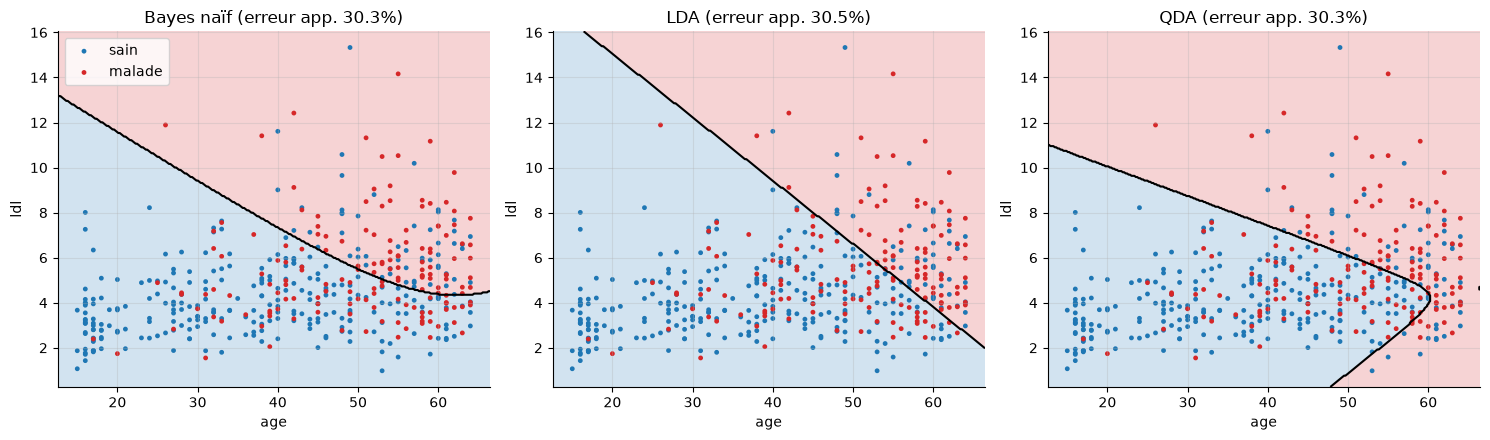

In [13]:
DEUX = ["age", "ldl"]
X2 = df[DEUX].to_numpy()

fig = utils.comparer_frontieres(
    {"Bayes naïf": GaussianNB(),
     "LDA": LinearDiscriminantAnalysis(),
     "QDA": QuadraticDiscriminantAnalysis()},
    X2, y, noms=DEUX)

**Réponse.**
- **LDA** : frontière **linéaire** (une droite), car la covariance commune fait disparaître les termes quadratiques en $x$ dans $\log\frac{P(1\mid x)}{P(0\mid x)}$.
- **QDA** : frontière **quadratique** (arc de conique), chaque classe ayant sa propre covariance.
- **Bayes naïf** : frontière aussi **quadratique**, mais une conique « alignée sur les axes » (covariances diagonales, pas de terme croisé $x_1 x_2$), car les variances diffèrent entre classes.

QDA est celle qui épouse le mieux la forme des nuages (elle se courbe pour suivre la classe « malade », plus dispersée), car c'est le modèle le plus flexible. Pourtant, dans ce plan, les trois erreurs d'apprentissage sont quasi identiques (≈ 30 %) : la courbure supplémentaire n'apporte presque rien. Ce n'est donc pas nécessairement la meilleure : sa courbure suit en partie le bruit de l'échantillon, se comporte de façon arbitraire loin des données, et l'exercice 3.1 a montré qu'en test c'est LDA qui l'emporte. Épouser les données ≠ bien généraliser.

## Exercice 4 — Évaluer autrement que par le taux d'erreur
### 4.1 Matrice de confusion

VP=25, FN=23, FP=22, VN=69
Précision (malade) = VP/(VP+FP) = 53.2%
Rappel    (malade) = VP/(VP+FN) = 52.1%


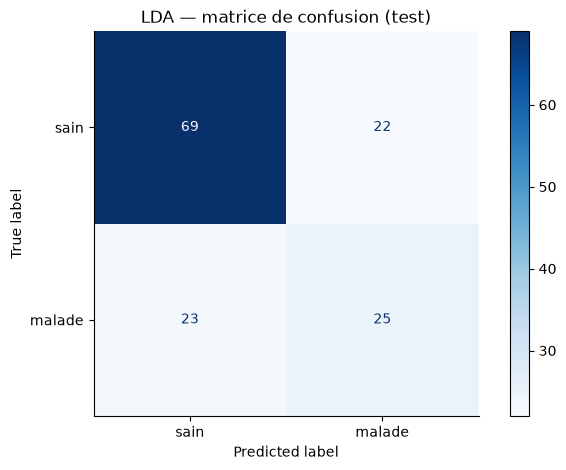

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_score, recall_score

meilleur = modeles["LDA"]           # meilleure erreur de test à l'exercice 3
y_pred = meilleur.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["sain", "malade"],
                                        cmap="Blues")
plt.title("LDA — matrice de confusion (test)")
plt.grid(False)

(vn, fp), (fn, vp) = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
rappel = recall_score(y_test, y_pred)
print(f"VP={vp}, FN={fn}, FP={fp}, VN={vn}")
print(f"Précision (malade) = VP/(VP+FP) = {precision:.1%}")
print(f"Rappel    (malade) = VP/(VP+FN) = {rappel:.1%}")

**Réponse.** Sur les 48 malades du test, LDA en détecte 25 et en manque 23 : rappel ≈ 52 %. **Sur 100 malades réels, le modèle en détecte environ 52** — à peine un sur deux. La précision est de 53 % : quand le modèle dit « malade », il a raison une fois sur deux environ.

Le taux d'erreur global (32 %) masque ce mauvais rappel, car la classe majoritaire « sain » est bien reconnue (69/91 ≈ 76 %).

### 4.2 Le coût n'est pas symétrique

Si un faux négatif coûte $c_{FN}$ et un faux positif $c_{FP}$, la décision de Bayes minimisant le coût moyen déclare « malade » dès que
$c_{FN}\,P(1\mid x) > c_{FP}\,P(0\mid x)$, soit
$$P(1\mid x) > \frac{c_{FP}}{c_{FP}+c_{FN}} = \frac{1}{1+5} \approx 0{,}17.$$

seuil 0.500 : rappel 52.1%, précision 53.2%, coût 137
seuil 0.167 : rappel 93.8%, précision 43.7%, coût 73
seuil 0.140 : rappel 100.0%, précision 43.2%, coût 63


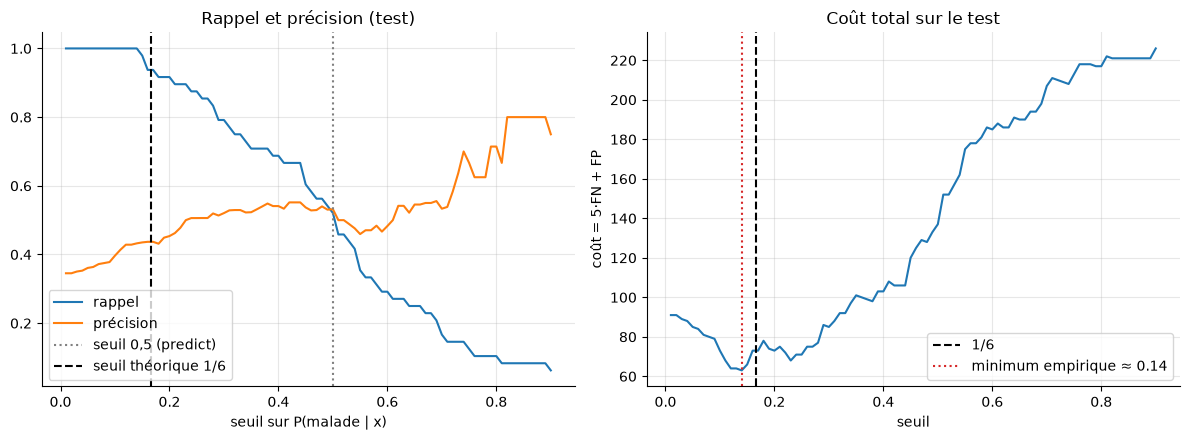

In [15]:
proba = meilleur.predict_proba(X_test)[:, 1]
seuils = np.linspace(0.01, 0.9, 90)

rappels, precisions, couts = [], [], []
for s in seuils:
    pred = (proba >= s).astype(int)
    rappels.append(recall_score(y_test, pred))
    precisions.append(precision_score(y_test, pred, zero_division=1))
    fn_s = np.sum((pred == 0) & (y_test == 1))
    fp_s = np.sum((pred == 1) & (y_test == 0))
    couts.append(5 * fn_s + fp_s)
couts = np.array(couts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(seuils, rappels, label="rappel")
ax1.plot(seuils, precisions, label="précision")
ax1.axvline(0.5, ls=":", c="grey", label="seuil 0,5 (predict)")
ax1.axvline(1 / 6, ls="--", c="k", label="seuil théorique 1/6")
ax1.set_xlabel("seuil sur P(malade | x)"); ax1.legend(); ax1.set_title("Rappel et précision (test)")

ax2.plot(seuils, couts)
s_opt = seuils[np.argmin(couts)]
ax2.axvline(1 / 6, ls="--", c="k", label="1/6")
ax2.axvline(s_opt, ls=":", c="tab:red", label=f"minimum empirique ≈ {s_opt:.2f}")
ax2.set_xlabel("seuil"); ax2.set_ylabel("coût = 5·FN + FP"); ax2.legend()
ax2.set_title("Coût total sur le test")
fig.tight_layout()

for s in [0.5, 1 / 6, s_opt]:
    pred = (proba >= s).astype(int)
    print(f"seuil {s:.3f} : rappel {recall_score(y_test, pred):.1%}, "
          f"précision {precision_score(y_test, pred):.1%}, "
          f"coût {5 * np.sum((pred == 0) & (y_test == 1)) + np.sum((pred == 1) & (y_test == 0))}")

**Réponse.** Quand le seuil baisse, le rappel monte (on déclare plus de gens malades) et la précision baisse : c'est un compromis.

Si un faux négatif coûte 5 fois un faux positif, je choisirais un seuil **≈ 1/6 ≈ 0,17** (la valeur théorique ci-dessus, si les probabilités sont bien calibrées). Sur le test, cela fait passer le rappel de 52 % à 94 % (la précision baisse de 53 % à 44 %) et divise le coût total environ par deux par rapport au seuil 0,5 (73 contre 137). Le minimum empirique du coût tombe dans la même zone (≈ 0,14) ; on préfère la valeur théorique ou un seuil choisi par validation croisée plutôt que le minimum sur le test, qui serait choisi sur les données servant à l'évaluation (sur-ajustement du seuil).

### 4.3 Une seule estimation ne suffit pas

,Bayes naïf,LDA,QDA
mean,31.6%,29.6%,30.4%
std,3.0%,3.2%,3.6%
min,25.9%,23.0%,24.5%
max,38.1%,36.7%,38.1%


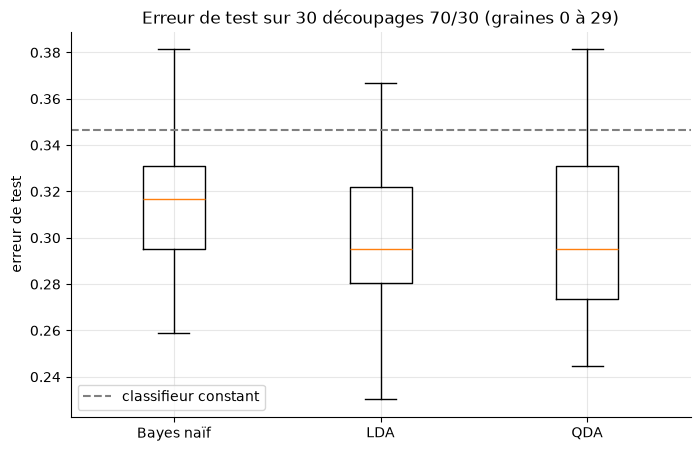

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

erreurs = {nom: [] for nom in modeles}
for graine in range(30):
    Xa, Xt, ya, yt = train_test_split(X, y, test_size=0.3, random_state=graine, stratify=y)
    for nom, m in modeles.items():
        erreurs[nom].append(1 - m.fit(Xa, ya).score(Xt, yt))
erreurs = pd.DataFrame(erreurs)

fig, ax = plt.subplots()
ax.boxplot([erreurs[c] for c in erreurs], tick_labels=list(erreurs.columns))
ax.axhline(erreur_constante, ls="--", c="grey", label="classifieur constant")
ax.set_ylabel("erreur de test"); ax.legend()
ax.set_title("Erreur de test sur 30 découpages 70/30 (graines 0 à 29)")

erreurs.agg(["mean", "std", "min", "max"]).style.format("{:.1%}")

In [17]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=GRAINE)
res_cv = {}
for nom, m in modeles.items():
    scores = cross_val_score(m, X, y, cv=cv)      # exactitude sur chaque pli
    res_cv[nom] = {"erreur CV (moyenne)": 1 - scores.mean(),
                   "écart-type entre plis": scores.std()}
pd.DataFrame(res_cv).T.style.format("{:.1%}")

,erreur CV (moyenne),écart-type entre plis
Bayes naïf,30.7%,3.9%
LDA,28.5%,6.2%
QDA,32.0%,5.7%


**Réponse.** D'une graine à l'autre, l'erreur de test d'un même modèle varie de plusieurs points (écart-type ≈ 3 points, écart min–max ≈ 13 points) : c'est plus que les écarts entre modèles. Le classement de l'exercice 3 (LDA < Bayes naïf < QDA en test) dépend de la graine : en moyenne sur 30 découpages, c'est LDA < QDA < Bayes naïf. Seule la supériorité de LDA paraît assez stable.

Dans un rapport, je ferais figurer **l'estimation par validation croisée stratifiée à 10 plis, accompagnée de sa dispersion** (écart-type entre plis) : elle utilise toutes les observations pour l'évaluation (chacune exactement une fois en test), dépend beaucoup moins d'un tirage particulier, et donne une idée de l'incertitude. Une erreur de test isolée sur 139 observations et une seule graine est trop bruitée.

## Remarque finale — À retenir
- Le classifieur constant fait 34,6 % d'erreur. C'est le plancher à battre.
- QDA gagne toujours sur l'apprentissage et pas toujours sur le test : plus de paramètres, plus de variance.
- Le taux d'erreur global masque le rappel quand les classes sont déséquilibrées.
- Le seuil 0,5 est une convention, pas un optimum.
- Une estimation sans dispersion est incomplète.